# Analisi statistica

In [30]:
# importo le librerie utili
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# importo il file csv
df = pd.read_csv('df_finale.csv',sep=';',keep_default_na=False)

In [32]:
# inizio a vedere le principali metriche per farmi un'idea sui dati che ho
df.describe().round(2)

,Codice comune,Anno,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
count,190900.00,190900.00,190900.00,190900.00,190900.00,190900.00,190900.0
mean,44492.22,2012.34,37.70,7423.75,35.10,0.53,25.0
std,32071.71,6.86,50.40,41024.15,338.34,2.79,257.7
min,1001.00,2001.00,0.12,28.00,0.00,0.00,0.0
25%,16137.00,2006.00,11.33,1032.00,1.00,0.00,1.0
50%,38009.00,2012.00,22.13,2442.00,5.00,0.00,3.0
75%,71048.00,2018.00,43.81,6115.25,18.00,0.00,12.0
max,111107.00,2024.00,1288.19,2820219.00,30254.00,363.00,23135.0


## EDA
Ho deciso di analizzare nello specifico le metriche legate agli incidenti perchè sono quelle che mi aiuteranno a rispondere alle richieste del compito (dove investire per la sicurezza stradale).
i restanti dati legati ai comuni, superficie anno e popolazione residente li userò a supporto dei valori che andrò ad usare/presentare 

### analisi dei valori max 

quelli che a un primo momento mi potevano sembrare degli outlier ( i max), per via della differenza tra valore max e le altre metriche, alla fine ho riscontrato che tutti questi valori sono legati a Roma.
Essendo Roma la città con la popolazione più densa ha senso che questi valori siano concentrati su questo Comune in particolare.

In [33]:
# verifico con un filtro a cosa fa riferimenento il volore più alto dei feriti
df[df['Feriti'] == df['Feriti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135


In [34]:
# verifico con un filtro a cosa fa riferimenento il volore più alto degli incidenti

df[df['Incidenti'] == df['Incidenti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135


In [35]:
# verifico con un filtro a cosa fa riferimenento il volore più alto degli abitanti/residenti
df[df['Popolazione residente'] == df['Popolazione residente'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116095,58091,Roma,2018,Annuale,1287.3895,2820219,15551,148,11995


In [36]:
# verifico con un filtro a cosa fa riferimenento il volore più alto dei morti
df[df['Morti'] == df['Morti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116079,58091,Roma,2002,Annuale,1287.3371,2544815,26696,363,21330


### analisi della distruibuzione dati
Ho deciso di analizzare i dati inerenti agli incidenti con il boxplot, istogrammi e scatterplot perchè la differenza tra la media e mediana (nel .describe()) mi suggerisce la presenza di outliers che trascinano la media verso valori più alti indicando quindi una distribuzione dei valori non lineare (skewness positiva) perchè appunto abbiamo valori (bassi) legati a piccoli comuni (che sono la maggioranza) e valori (alti) legati a grandi comuni (che sono la minoranza).

### Boxplot

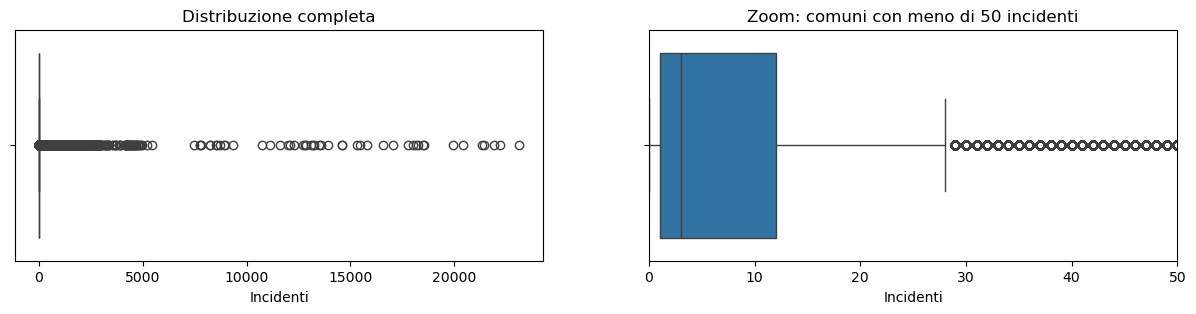

Q1: 1.0
Q2 (Mediana): 3.0
Q3: 12.0
Range interquartile: 11.0
il valore massimo accettato prima di essere considerato un outlier è:28.5


In [37]:
# creo una figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
# creo i boxplot
sns.boxplot(x=df['Incidenti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Incidenti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 incidenti')

plt.show()
# commento
print(f'Q1: {df['Incidenti'].quantile(0.25)}')
print(f'Q2 (Mediana): {df['Incidenti'].quantile(0.50)}')
print(f'Q3: {df['Incidenti'].quantile(0.75)}')
print(f'Range interquartile: {df['Incidenti'].quantile(0.75) - df['Incidenti'].quantile(0.25)}')
print(f'il valore massimo accettato prima di essere considerato un outlier è:{df['Incidenti'].quantile(0.75) + 1.5 * (df['Incidenti'].quantile(0.75) - df['Incidenti'].quantile(0.25))}')


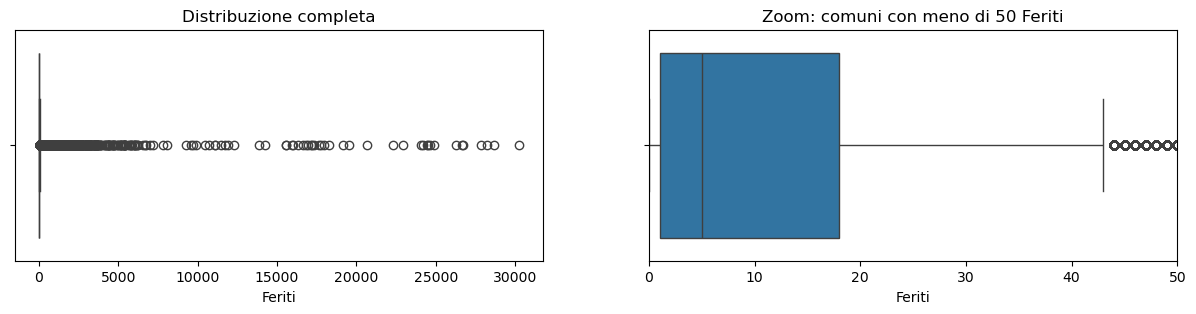

Q1: 1.0
Q2 (Mediana): 5.0
Q3: 18.0
Range interquartile: 17.0
il valore massimo accettato prima di essere considerato un outlier è:43.5


In [38]:
# creo una figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
# creo i boxplot
sns.boxplot(x=df['Feriti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Feriti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 Feriti')

plt.show()
# commento
print(f'Q1: {df['Feriti'].quantile(0.25)}')
print(f'Q2 (Mediana): {df['Feriti'].quantile(0.50)}')
print(f'Q3: {df['Feriti'].quantile(0.75)}')
print(f'Range interquartile: {df['Feriti'].quantile(0.75) - df['Feriti'].quantile(0.25)}')
print(f'il valore massimo accettato prima di essere considerato un outlier è:{df['Feriti'].quantile(0.75) + 1.5 * (df['Feriti'].quantile(0.75) - df['Feriti'].quantile(0.25))}')

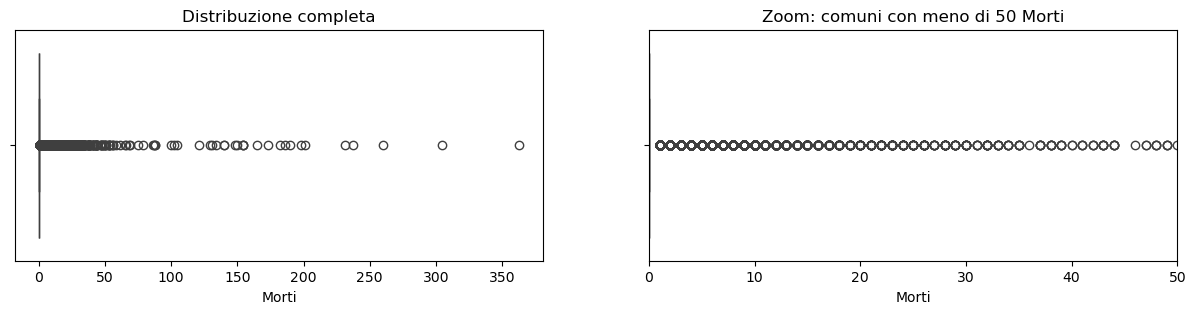

Q1: 0.0
Q2 (Mediana): 0.0
Q3: 0.0
Range interquartile: 0.0
il valore massimo accettato prima di essere considerato un outlier è:0.0
vuol dire che qualsiasi valore sopra a 0 è outlier


In [39]:
# creo una figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
# creo i boxplot
sns.boxplot(x=df['Morti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Morti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 Morti')

plt.show()
# commento
print(f'Q1: {df['Morti'].quantile(0.25)}')
print(f'Q2 (Mediana): {df['Morti'].quantile(0.50)}')
print(f'Q3: {df['Morti'].quantile(0.75)}')
print(f'Range interquartile: {df['Morti'].quantile(0.75) - df['Morti'].quantile(0.25)}')
print(f'il valore massimo accettato prima di essere considerato un outlier è:{df['Morti'].quantile(0.75) + 1.5 * (df['Morti'].quantile(0.75) - df['Morti'].quantile(0.25))}')
print(f'vuol dire che qualsiasi valore sopra a 0 è outlier')

In [40]:
# ora grazie a queste analisi volendo posso risalire a dei dati specifici, come ad esempio risalire a tutti i comuni con un numero di incidenti statisticamente elevato:
df[df['Incidenti'] >= 28.5].sort_values('Incidenti',ascending=False).head(5)

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135
116078,58091,Roma,2001,Annuale,1287.3372,2545977,27865,305,22220
116082,58091,Roma,2005,Annuale,1287.3371,2565386,28653,237,21902
116083,58091,Roma,2006,Annuale,1287.3371,2586029,28209,231,21452
116079,58091,Roma,2002,Annuale,1287.3371,2544815,26696,363,21330


### Istogramma 

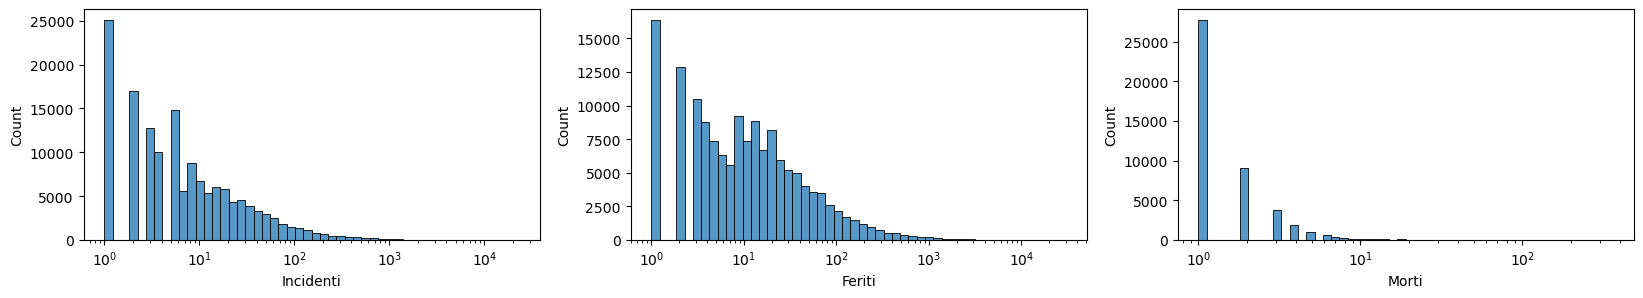

Incidenti: ha una skewed positiva, i valori sono più accorpati a sinitra quindi la maggior parte dei comuni non ha molti incidenti. dove non ci sono colonne è perchè non ci sono dati/valori dentro a quel specifico range di incidenti
Feriti: ha una skewed positiva, in questo caso i valori sono distribuiti più verso destra. questo mi fa capire che, per logica, un incidente può causare più di un ferito e per questo vedo valori più alti
Morti: ha una skewed positiva, più marcata rispetto agli altri dati ma perchè i pochi valori che abbiamo si concentrano su un valore basso. i vuoti sono dovuti al fatto che sono eventi più rari e concentrati, quindi molti range non hanno dati.
Conclusione: il numero di incidenti sembra attenuarsi su valori bassi per la maggior parte dei comuni ma questo non implica meno feriti... anzi vedo che quelli hanno distribuzione maggiore per i vari range mentre per i morti sembrerebbe essere un evento più raro ma non impossibile.


In [41]:
# creo una figura con 3 grafici affiancati
fig, axes = plt.subplots(1, 3, figsize=(20, 3))
# creo gli istogrammi
sns.histplot(x='Incidenti', data=df, bins=50, ax=axes[0],log_scale=True)
sns.histplot(x='Feriti', data=df, bins=50, ax=axes[1],log_scale=True)
sns.histplot(x='Morti', data=df, bins=50, ax=axes[2],log_scale=True)
plt.show()
#commnto
print(f'Incidenti: ha una skewed positiva, i valori sono più accorpati a sinitra quindi la maggior parte dei comuni non ha molti incidenti. dove non ci sono colonne è perchè non ci sono dati/valori dentro a quel specifico range di incidenti')
print(f'Feriti: ha una skewed positiva, in questo caso i valori sono distribuiti più verso destra. questo mi fa capire che, per logica, un incidente può causare più di un ferito e per questo vedo valori più alti')
print(f'Morti: ha una skewed positiva, più marcata rispetto agli altri dati ma perchè i pochi valori che abbiamo si concentrano su un valore basso. i vuoti sono dovuti al fatto che sono eventi più rari e concentrati, quindi molti range non hanno dati.')
print(f'Conclusione: il numero di incidenti sembra attenuarsi su valori bassi per la maggior parte dei comuni ma questo non implica meno feriti... anzi vedo che quelli hanno distribuzione maggiore per i vari range mentre per i morti sembrerebbe essere un evento più raro ma non impossibile.')

### Scatterplot

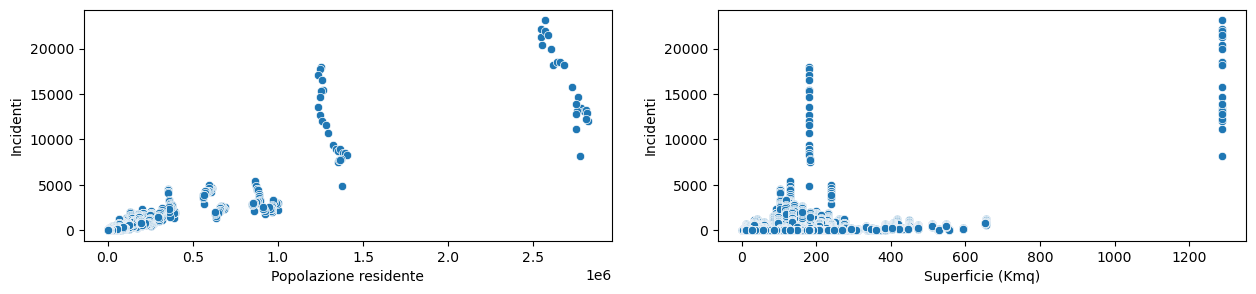

Dallo scatterplot tra popolazione e incidenti noto una relazione positiva ovvero che i comuni con più abitanti tendono ad avere più incidenti. I comuni con meno di 1mln di abitanti non superano i 5000 incidenti mentre i grossi comuni più isolati hanno un impennata di incidenti.
Dallo scatterplot tra superficie e incidenti vedo una relazione meno netta rispetto al grafico precedente.. gli incidenti si concentrano tutti attorno ai 200 kmq e mi fa pensare che la maggior parte dei comuni non si estende molto.. mentre Roma come sempre si posiziona da sola a destra


In [42]:
# visualizzo il numero di incidenti per numero abitanti e numero incidenti per kmq
# creo una figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
sns.scatterplot(x='Popolazione residente',y='Incidenti', data=df, ax=axes[0])
sns.scatterplot(x='Superficie (Kmq)', y='Incidenti', data=df, ax=axes[1])
plt.show()
#commento
print(f'Dallo scatterplot tra popolazione e incidenti noto una relazione positiva ovvero che i comuni con più abitanti tendono ad avere più incidenti. I comuni con meno di 1mln di abitanti non superano i 5000 incidenti mentre i grossi comuni più isolati hanno un impennata di incidenti.')
print(f'Dallo scatterplot tra superficie e incidenti vedo una relazione meno netta rispetto al grafico precedente.. gli incidenti si concentrano tutti attorno ai 200 kmq e mi fa pensare che la maggior parte dei comuni non si estende molto.. mentre Roma come sempre si posiziona da sola a destra')

### Top 10 comuni per incidenti 

In [43]:
# tabella che raggrupa per comuni in ordine decrescente per incidenti
df.groupby(['Codice comune','Comune'])[['Incidenti','Feriti','Morti']].sum().sort_values('Incidenti', ascending=False).head(10)

,,Incidenti,Feriti,Morti
Codice comune,Comune,,,
58091,Roma,390605,506345,4350
15146,Milano,272545,355984,1435
10025,Genova,102694,128139,580
1272,Torino,87227,129752,895
48017,Firenze,74537,90339,425
63049,Napoli,60731,83636,881
82053,Palermo,54030,73910,716
37006,Bologna,53858,70091,565
72006,Bari,44172,66703,357


Ho provato a riordinare anche per feriti e morti.. non cambia molto la tabella, cambia solo di 1 / 2 comuni. quindi questi sarebbero una buona base di partenza su cui potersi focalizzare

### Trend degli incidenti

In [44]:
# raggruppo tutto per anno e calcolo la somma degli incidenti
df_trend = df.groupby('Anno')[['Incidenti','Morti','Feriti']].sum()
#print(df_trand.shape) per verificare che ci siano 24 righe
df_trend

,Incidenti,Morti,Feriti
Anno,,,
2001,263100,7096,373286
2002,265402,6980,378491
2003,252261,6561,356463
2004,243490,6122,343179
2005,240011,5818,334858
2006,238124,5669,332955
2007,230871,5131,325850
2008,218963,4725,310745
2009,210256,4149,299734


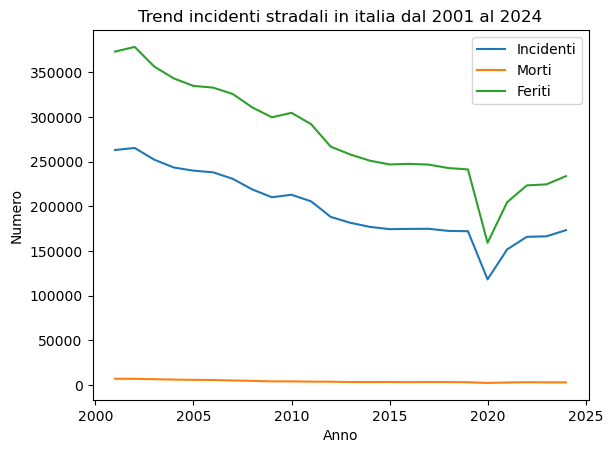

il grafico mostra che dagli anni 2000 al 2020 ce stato un calo sostenuto e si vede come periodo covid gli incidenti siano diminuiti di netto per poi riprendere a salire post lockdown ai lv precedenti.


In [45]:
df_trend.plot()
plt.title('Trend incidenti stradali in italia dal 2001 al 2024')
plt.xlabel('Anno')
plt.ylabel('Numero')
plt.show()

print(f'il grafico mostra che dagli anni 2000 al 2020 ce stato un calo sostenuto e si vede come periodo covid gli incidenti siano diminuiti di netto per poi riprendere a salire post lockdown ai lv precedenti.')

### Colonne calcolate - Incidenti per capita e incidenti per kmq

In [46]:
# ho deciso di fare ogni mille abitanti per rendere il dato più leggibile
df['Incidenti pro capite (1000 abitanti)'] = (df['Incidenti'] / df['Popolazione residente'])*1000
# calcolo quanti incidenti ci sono per kmq 
df['Incidenti per kmq'] = df['Incidenti'] / df['Superficie (Kmq)']
df.head()

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti,Incidenti pro capite (1000 abitanti),Incidenti per kmq
0,1001,Agliè,2001,Annuale,13.1462,2557,10,0,5,1.955417,0.380338
1,1001,Agliè,2002,Annuale,13.1462,2538,10,0,5,1.970055,0.380338
2,1001,Agliè,2003,Annuale,13.1462,2588,7,0,4,1.545595,0.304270
3,1001,Agliè,2004,Annuale,13.1462,2679,13,0,9,3.359462,0.684608
4,1001,Agliè,2005,Annuale,13.1462,2674,2,0,2,0.747943,0.152135


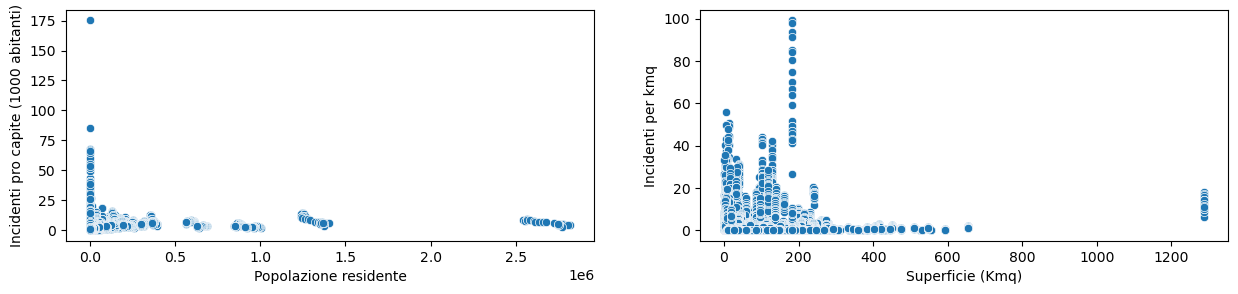

Dallo scatterplot tra popolazione e incidenti pro capite noto che i piccoli comuni hanno un tasso più alto di incidenti a differenza delle grandi città.
non so quanto fidarmi però del dato essendo che ho calcato la colonna per ogni mille abitanti e sapendo che dentro i piccoli comunici ci sono quelli con meno di mille abitanti
Dallo scatterplot tra superfice e incidenti per kmq noto lo stesso pattern, concentrazione di incidenti sui comuni più piccoli con un picco nei comuni con 200kmq mentre per le grandi città sembra essere più contenuto.
un osservazione che mi viene in mente è che i comuni più piccoli potrebbero essere meno attrezzati rispetto a quelli più grandi in prevenzione degli incidenti, ma è un dato da verifcare visto che ho fatto la conversione in mille abitanti e so esserci comuni che ne hanno meno


In [47]:
# visualizzo i dati sullo scatterplot per vedere meglio cosa mi dicono
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
sns.scatterplot(x='Popolazione residente',y='Incidenti pro capite (1000 abitanti)', data=df, ax=axes[0])
sns.scatterplot(x='Superficie (Kmq)', y='Incidenti per kmq', data=df, ax=axes[1])
plt.show()
#commento
print(f'Dallo scatterplot tra popolazione e incidenti pro capite noto che i piccoli comuni hanno un tasso più alto di incidenti a differenza delle grandi città.')
print(f'non so quanto fidarmi però del dato essendo che ho calcato la colonna per ogni mille abitanti e sapendo che dentro i piccoli comunici ci sono quelli con meno di mille abitanti')
print(f'Dallo scatterplot tra superfice e incidenti per kmq noto lo stesso pattern, concentrazione di incidenti sui comuni più piccoli con un picco nei comuni con 200kmq mentre per le grandi città sembra essere più contenuto.')
print(f'un osservazione che mi viene in mente è che i comuni più piccoli potrebbero essere meno attrezzati rispetto a quelli più grandi in prevenzione degli incidenti, ma è un dato da verifcare visto che ho fatto la conversione in mille abitanti e so esserci comuni che ne hanno meno')

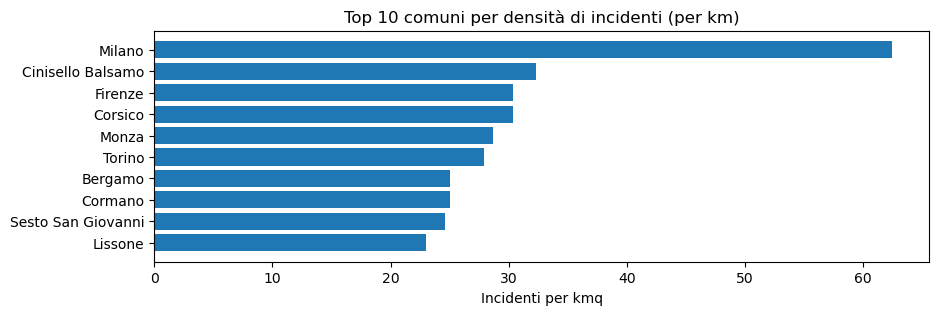

il grafico, a sorpresa, non mi mostra gli stessi comuni visti nel top 10 per incidenti ma conferma quanto visto nei 2 scatterplort sopra.. ovvero che i comuni più a rischio sembrerebbero essere quelli con meno superficie ma con alta densità di popolazione


In [48]:
# creo una tabella con dentro i top 10 comuni con incidenti per kmq
top10 = df.groupby(['Codice comune','Comune'])['Incidenti per kmq'].mean().sort_values(ascending=False).head(10).reset_index()
# creo il grafico a barre per visualizzare meglio i dati e confrontarlo coi scatterplot sopra
fig, ax = plt.subplots(figsize=(10, 3))
plt.barh(top10['Comune'], top10['Incidenti per kmq'])
plt.xlabel('Incidenti per kmq')
plt.title('Top 10 comuni per densità di incidenti (per km)')
plt.gca().invert_yaxis()
plt.show()

print(f'il grafico, a sorpresa, non mi mostra gli stessi comuni visti nel top 10 per incidenti ma conferma quanto visto nei 2 scatterplort sopra.. ovvero che i comuni più a rischio sembrerebbero essere quelli con meno superficie ma con alta densità di popolazione')

## Clustering

In [49]:
# creo la tabella per il cluster usando le colonne calcolato, uso la media e non la somma per avitare che i valori di comuni piccoli o grandi possano sfalsare o far sembrare un comune peggio/meglio rispetto agli altri
df_cluster = df.groupby(['Codice comune'])[['Incidenti pro capite (1000 abitanti)','Incidenti per kmq']].mean()
print(f'ora che ho una riga singola per ogni comune posso procedere col categorizzarli')
df_cluster

ora che ho una riga singola per ogni comune posso procedere col categorizzarli


,Incidenti pro capite (1000 abitanti),Incidenti per kmq
Codice comune,,
1001,1.503771,0.301101
1002,2.967542,0.693593
1003,0.543898,0.005396
1004,2.635785,0.380004
1005,1.717134,0.158093
...,...,...
111103,1.322371,0.033085
111104,2.275920,0.017260
111105,1.820392,0.116192


In [50]:
# importo la libreria che serve
from sklearn.preprocessing import MinMaxScaler

#creo la variabile che dovrò usare per standarizzare i dati (valore-minimo)/(massimo-minimo)
scale_norm = MinMaxScaler()
# adesso eseguo la funzione al df_cluster così da avere valori tra lo 0 e 1 e gli riassegno le colonne 
df_scaled = pd.DataFrame(scale_norm.fit_transform(df_cluster), columns=df_cluster.columns)
# il fatto che non ci siano più i comuni come indice non è un errore
df_scaled.head()

,Incidenti pro capite (1000 abitanti),Incidenti per kmq
0,0.062133,0.004818
1,0.122614,0.011097
2,0.022473,0.000086
3,0.108906,0.006080
4,0.070949,0.002529


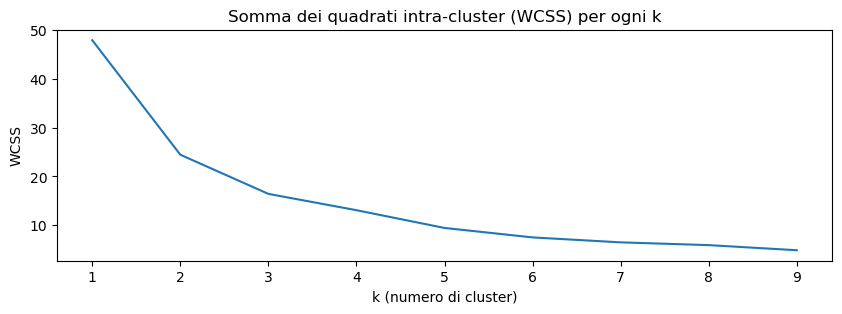

Ho scelto 3 come valore perchè si sposa a quelle che sono le nostre esigenze di categorizzazione e perchè è il punto dove vedo inizia a stabilizzarsi la curva


In [51]:
# qui commento ogni passaggio per aiutarmi essendo solo la seconda volta (post lezioni) che faccio un cluster
# importo la libreria che serve
from sklearn.cluster import KMeans
# uso più k così nel ciclo for può eseuire più prove con più centroidi e dopo posso valutare dal wcss quale combinazine scegliere
k_values = list(range(1,10))
# qui sto creando dove mettere tutti i valori restitui dal ciclo for
wcss_list = []

for k in k_values:
    # qui assegno alla variabile la funzione che a ogni giro usa k diverse ma con lo stesso metodo randomico
    Kmeans = KMeans(n_clusters=k, random_state= 42)
    # qui praticamente, come visto a lezione, eseguo la funzione sul df così da provare le varie combinazioni
    Kmeans.fit(df_scaled)
    # salvo il valore WCSS (inertia), più è basso e più i punti dentro ogni cluster sono vicini tra loro
    wcss_list.append(Kmeans.inertia_)

plt.figure(figsize=(10,3))
plt.plot(k_values, wcss_list)
plt.title('Somma dei quadrati intra-cluster (WCSS) per ogni k')
plt.xlabel("k (numero di cluster)")
plt.ylabel("WCSS")
plt.show()
print(f'Ho scelto 3 come valore perchè si sposa a quelle che sono le nostre esigenze di categorizzazione e perchè è il punto dove vedo inizia a stabilizzarsi la curva')

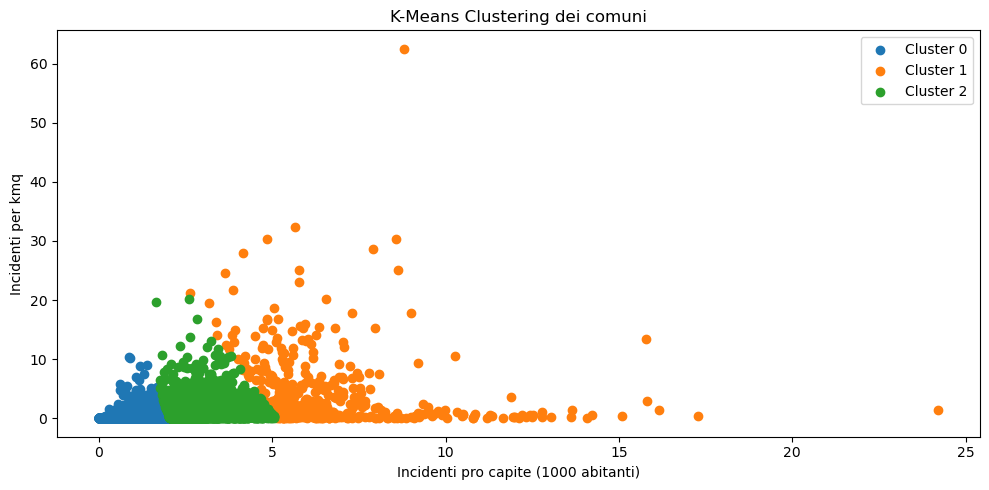

grazie a questo grafico ora capisco ogni cluster che categoria rappresenta per rinominare i valori numerici in qualcosa di più intuitivo


In [52]:
# creo il cluster con k=3 e tengo lo stesso metodo randomico (42)
kmeans_final = KMeans(n_clusters=3, random_state=42)
# rieseguo la funzione ma con i valori settati
kmeans_final.fit(df_scaled)
# aggiungo la colonna cluster al df creato inizialmente, così ora per ogni comune ho la sua categoria 
df_cluster['cluster'] = kmeans_final.labels_

# salvo le coordinate finali dei 3 centroidi (non usate nel grafico, calcolate solo per completezza)
centroids = kmeans_final.cluster_centers_
# mostro graficamente la classificazione dei comuni fatta sulla media degli incidenti pro capite e incidenti per mkq 
clusters = df_cluster.groupby('cluster')
plt.figure(figsize=(10, 5))
for cluster, data in clusters:
    plt.scatter(data['Incidenti pro capite (1000 abitanti)'], data['Incidenti per kmq'], marker='o', label=f'Cluster {cluster}')
plt.xlabel('Incidenti pro capite (1000 abitanti)')
plt.ylabel('Incidenti per kmq')
plt.title('K-Means Clustering dei comuni')
plt.legend()
plt.tight_layout()
plt.show()

print(f'grazie a questo grafico ora capisco ogni cluster che categoria rappresenta per rinominare i valori numerici in qualcosa di più intuitivo')

In [53]:
# prima di rinominare i valori verifico anche con un group by che il grafico sia corretto
df_cluster.groupby('cluster')[['Incidenti pro capite (1000 abitanti)','Incidenti per kmq']].mean()

,Incidenti pro capite (1000 abitanti),Incidenti per kmq
cluster,,
0,1.023994,0.240721
1,6.619823,4.067418
2,2.959809,1.053899


In [54]:
# converto i cluster numerici in nomenclature più chiare e comode
df_cluster['cluster'] = df_cluster['cluster'].astype(str).replace({'0': 'Basso rischio', '1': 'Alto rischio', '2': 'Medio rischio'})
df_cluster.head(10)

,Incidenti pro capite (1000 abitanti),Incidenti per kmq,cluster
Codice comune,,,
1001,1.503771,0.301101,Basso rischio
1002,2.967542,0.693593,Medio rischio
1003,0.543898,0.005396,Basso rischio
1004,2.635785,0.380004,Medio rischio
1005,1.717134,0.158093,Basso rischio
1006,0.850940,0.296030,Basso rischio
1007,1.181030,0.054089,Basso rischio
1008,1.908602,2.709192,Medio rischio
1009,1.138210,0.294995,Basso rischio


In [55]:
# sistemo gli indici prima di fare la join ed escludo le altre colonne
df_cluster_merge = df_cluster[['cluster']].reset_index()
df_cluster_merge

,Codice comune,cluster
0,1001,Basso rischio
1,1002,Medio rischio
2,1003,Basso rischio
3,1004,Medio rischio
4,1005,Basso rischio
...,...,...
8573,111103,Basso rischio
8574,111104,Medio rischio
8575,111105,Basso rischio
8576,111106,Basso rischio


In [56]:
df_completo = df.merge(df_cluster_merge,how='left',on=['Codice comune'])
df_completo.head()

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti,Incidenti pro capite (1000 abitanti),Incidenti per kmq,cluster
0,1001,Agliè,2001,Annuale,13.1462,2557,10,0,5,1.955417,0.380338,Basso rischio
1,1001,Agliè,2002,Annuale,13.1462,2538,10,0,5,1.970055,0.380338,Basso rischio
2,1001,Agliè,2003,Annuale,13.1462,2588,7,0,4,1.545595,0.304270,Basso rischio
3,1001,Agliè,2004,Annuale,13.1462,2679,13,0,9,3.359462,0.684608,Basso rischio
4,1001,Agliè,2005,Annuale,13.1462,2674,2,0,2,0.747943,0.152135,Basso rischio


In [57]:
# verifico che sia tutto ok
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190900 entries, 0 to 190899
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Codice comune                         190900 non-null  int64  
 1   Comune                                190900 non-null  object 
 2   Anno                                  190900 non-null  int64  
 3   Frequenza                             190900 non-null  object 
 4   Superficie (Kmq)                      190900 non-null  float64
 5   Popolazione residente                 190900 non-null  int64  
 6   Feriti                                190900 non-null  int64  
 7   Morti                                 190900 non-null  int64  
 8   Incidenti                             190900 non-null  int64  
 9   Incidenti pro capite (1000 abitanti)  190900 non-null  float64
 10  Incidenti per kmq                     190900 non-null  float64
 11  

## Creazione file CSV finale per PowerBi

In [58]:
df_completo.to_csv('df_completo.csv', sep=';', index=False,decimal=',')